# HTTP/3 Benchmarks

In [1]:
import math
from common import *
from experiment import *
from data.http import HTTPExperiment
from treatments.picoquic import treatment_map
from treatments.network_settings import *

## Network Settings

In [2]:
N_TRIALS = 20

labels_cubic = [
    # IBLT with configured ACK delays
    f'picoquic_iblt_{ACK_DELAY_WIFI}ms_hint',
    f'picoquic_iblt_{ACK_DELAY_SAT}ms_hint',
    f'picoquic_iblt_{ACK_DELAY_CELL}ms_hint',
    f'picoquic_iblt_{ACK_DELAY_SAT_LONG}ms_hint',
    # End-to-end
    'picoquic',
    'picoquic_split',
    #'picoquic_rtunnel_retx7',
    #'picoquic_rtunnel_retx7_ordered32',
]

labels_bbr = [l + "_bbr" for l in labels_cubic]

# Protocol and proxy configurations
treatments_cubic = [treatment_map(label) for label in labels_cubic]
treatments_bbr = [treatment_map(label) for label in labels_bbr]

# Network settings
LOSS1_VALUES = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10]
networks = network_settings(LOSS1_VALUES)

max_networks = {'picoquic' : 10, 'picoquic_rtunnel_retx' : 14}

# Data transfer size; aim for 10s transfer under optimal conditions
BPS = 125000 # 1Mbps = 125,000 bytes
def DATA_SIZE_(bottleneck_bw=20, time_s=10):
    return bottleneck_bw * BPS * time_s

def DATA_SIZE(network: NetworkSetting, time_s=10):
    return DATA_SIZE_(bottleneck_bw=min(network.get('bw1'), network.get('bw2')), time_s=time_s)

## Plotting and Data Collection Helpers

In [3]:
def plot_loss_vs_metric_line(data, title, ylabel, ncol=3, ylim=0, delta=25, pdf=None, style=False, ge=False):
    plt.figure(figsize=(6, 3))
    
    keys = data.treatments
    data_size = data.data_sizes[0]

    # Plot each label
    labels = []
    for key in keys:
        xs = []
        ys_raw = []

        for network in data.network_settings:
            if data_size not in data.data[key][network]:
                continue
            network_setting = data.exp.get_network_setting(network)
            
            if ge:
                xs.append(ge_to_burst_size(network_setting.settings['ge']))
            else:
                xs.append(float(network_setting.settings['loss1']))
                
            ys_raw.append(data.data[key][network][data_size])

        ys = [y.p(50) for y in ys_raw]
        yerr_lower = [y.p(50) - y.p(50-delta) for y in ys_raw]
        yerr_upper = [y.p(50+delta) - y.p(50) for y in ys_raw]
        if style:
            label = LABEL_MAP[key]
            sty = STYLE[label]
            title = None
            ylim = None
            plt.errorbar(xs, ys, yerr=(yerr_lower, yerr_upper), marker=sty.marker, markersize=sty.markersize, capsize=5, label=label, color=sty.color, linestyle=sty.linestyle)
        else:
            label = key
            plt.errorbar(xs, ys, yerr=(yerr_lower, yerr_upper), marker='.', capsize=5, label=label)
        print(label, list(zip(xs, ys)))
        labels.append(label)

    plt.title(title)
    if ge:
        plt.xlabel('Expected Length (Packets) of Lossy Burst')
    else: 
        plt.xlabel('IP Loss % Near Data Receiver')
    plt.ylabel(ylabel)
    plt.grid()
    plt.xlim(0)
    plt.ylim(ylim)
    plot_title_and_legend(title, labels, base_height=1.2, row_height=0.07, title_height=0.08, ncol=ncol)
    if pdf:
        save_pdf(pdf)
    plt.show()

def collect_loss_vs_metric_data(treatments, network_settings, data_size, n=10, max_networks=max_networks, execute=False, min_i=1):
    if execute:
        num_trials_range = range(min_i, n+1)
    else:
        num_trials_range = [n]
    for i in num_trials_range:
        exp = HTTPExperiment(num_trials=i, treatments=treatments, network_settings=network_settings, data_sizes=[data_size])
        raw_data = exp.to_raw_data(execute=execute, max_networks=max_networks)
    return raw_data

def plot_loss_vs_throughput(raw_data, title=None, ncol=2, pdf=None, style=False, ge=False):
    plottable_data = raw_data.to_plottable_data('throughput_mbps')
    if not title:
        title = f'{data_size_str(plottable_data.data_sizes[0])} ({plottable_data.network_settings[0]})'
    ylabel = 'Goodput (Mbit/s)'
    plot_loss_vs_metric_line(plottable_data, title, ncol=ncol, ylabel=ylabel, pdf=pdf, style=style, ge=ge)
    

In [4]:
def exec_single(treatments, network_settings, label, execute=False, ge=False, max_networks_=max_networks):
    try: 
        loss_vs_throughput_data = collect_loss_vs_metric_data(
            n=N_TRIALS,
            execute=execute,
            treatments=treatments,
            max_networks=max_networks_,
            network_settings=network_settings,
            data_size=DATA_SIZE(network_settings[0]),
        )
        plot_loss_vs_throughput(loss_vs_throughput_data, pdf=f"../figures/{label}.pdf", style=True, ge=ge)
    except Exception as e:
        print(f"Error: {e}")

max_networks_ge = {}

def exec_single_ge(loss, net_key, ack_delay):
    treatments = [t for t in treatments_cubic if ('iblt' not in t.label() or f'{ack_delay}ms' in t.label())]
    networks_ge = network_settings_ge(loss)
    exec_single(treatments=treatments, network_settings=networks_ge[net_key], label=f"http_benchmark_{net_key}_cubic_ge_{loss}pct", execute=True, ge=True, max_networks_=max_networks_ge)

## Packrat vs. End-to-End

Packrat [(0.0, 18.434897924738436), (1.0, 18.4585090681001), (2.0, 18.45573685487682), (3.0, 18.425955226399516), (4.0, 18.410458126129413), (5.0, 18.395038561623675), (6.0, 18.386890689084467), (7.0, 18.119640810182283), (8.0, 18.08607114232921), (10.0, 17.17427176177812)]
End-to-End [(0.0, 18.505101489160992), (1.0, 18.311678789097655), (2.0, 16.520795802989376), (3.0, 10.892711264504715), (4.0, 6.788554765533933), (5.0, 4.634019917365077), (6.0, 3.504319975500283), (7.0, 2.872453767641124), (8.0, 2.305887972775987), (10.0, 1.720879339544157)]
Split Connection [(0.0, 18.578001669913494), (1.0, 18.580464637749216), (2.0, 18.576639320234495), (3.0, 18.57749360913504), (4.0, 18.57088979595244), (5.0, 18.56707864188523), (6.0, 18.54764996115295), (7.0, 18.566643999818446), (8.0, 18.530941063201798), (10.0, 18.437613851596517)]
../figures/http_benchmark_wifi_cubic_solo.pdf


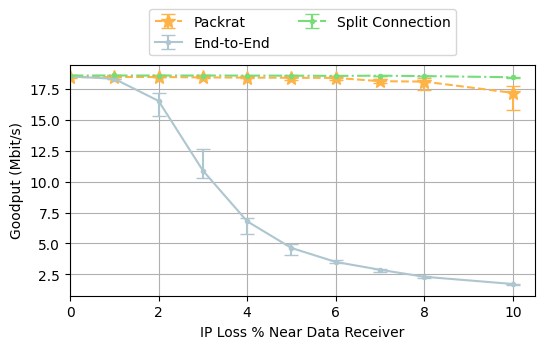

In [5]:
treatments = [treatment_map(label) for label in [f'picoquic_iblt_{ACK_DELAY_WIFI}ms_hint', 'picoquic', 'picoquic_split']]
exec_single(treatments=treatments, network_settings=networks['wifi'], label="http_benchmark_wifi_cubic_solo", execute=True)

Packrat [(0.0, 18.27023859747943), (1.0, 18.041593436041616), (2.0, 17.212388547474916), (3.0, 15.270116089902237), (4.0, 13.127111306475735), (5.0, 12.049338179450551), (6.0, 10.868595133789377), (7.0, 10.03824395351111), (8.0, 9.373003123859517), (10.0, 8.296493189067943)]
End-to-End [(0.0, 18.389689539629998), (1.0, 18.192939132732185), (2.0, 17.620313397313943), (3.0, 9.885183354409513), (4.0, 6.141921432395983), (5.0, 3.8400044173993564), (6.0, 3.108254147005836), (7.0, 2.3912798291335493), (8.0, 1.9591687189824827), (10.0, 1.4316883019805287)]
Split Connection [(0.0, 18.52074874135463), (1.0, 18.5128266922361), (2.0, 18.508556535284683), (3.0, 18.47709267955767), (4.0, 16.429868509988363), (5.0, 12.208018150192363), (6.0, 9.620861268568646), (7.0, 7.568711875152319), (8.0, 6.290340552475358), (10.0, 4.674918264659638)]
../figures/http_benchmark_cell_cubic_solo.pdf


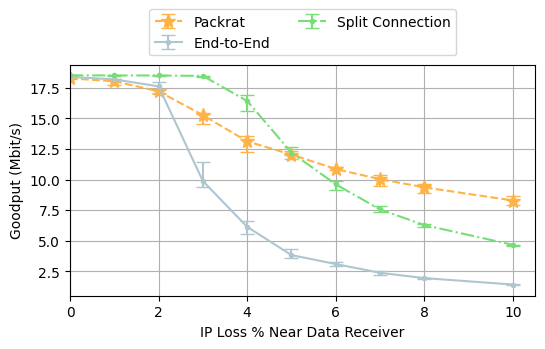

In [6]:
treatments = [treatment_map(label) for label in [f'picoquic_iblt_{ACK_DELAY_CELL}ms_hint', 'picoquic', 'picoquic_split']]
exec_single(treatments=treatments, network_settings=networks['cellular'], label="http_benchmark_cell_cubic_solo", execute=True)

Packrat [(0.0, 17.60600923090399), (1.0, 17.292438107289886), (2.0, 14.564253298353385), (3.0, 8.660501895047602), (4.0, 5.20715592632374), (5.0, 4.679049587541741), (6.0, 4.279700128465651), (7.0, 4.132188352612302), (8.0, 3.9436227498242955), (10.0, 3.8665974324073886)]
End-to-End [(0.0, 17.82487994087898), (1.0, 17.647023529498977), (2.0, 15.759349784481987), (3.0, 7.721788039672871), (4.0, 3.993019652803338), (5.0, 2.459938211832621), (6.0, 1.7139903859428354), (7.0, 1.3446420905169485)]
Split Connection [(0.0, 18.13297257671058), (1.0, 18.10080229441462), (2.0, 18.071492624168094), (3.0, 14.990114285076551), (4.0, 8.44287683082716), (5.0, 4.812949636246684), (6.0, 3.6654715901575137), (7.0, 2.9020290470226255), (8.0, 2.3601066899725422), (10.0, 1.6577325209934297)]
../figures/http_benchmark_sat_cubic_solo.pdf


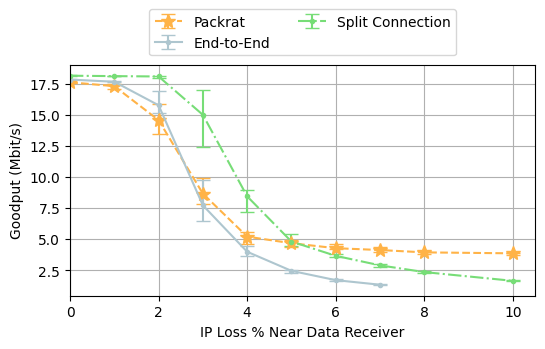

In [7]:
treatments = [treatment_map(label) for label in [f'picoquic_iblt_{ACK_DELAY_SAT}ms_hint', 'picoquic', 'picoquic_split']]
LOSS1_VALUES_ = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10]
max_networks_sat = {'picoquic' : 8}
networks_ = network_settings(LOSS1_VALUES_)
exec_single(treatments=treatments, network_settings=networks_['sat'], max_networks_=max_networks_sat, label="http_benchmark_sat_cubic_solo", execute=True)

Packrat [(0.0, 18.155066691596495), (1.0, 17.94783127042991), (2.0, 17.932994632212136), (3.0, 17.85717637160314), (4.0, 17.848312445462398), (5.0, 17.757091277091668), (6.0, 17.70624474303054), (7.0, 17.602748633702397), (8.0, 17.319981142644508), (10.0, 17.304759811820162)]
End-to-End [(0.0, 18.197131895940004), (1.0, 15.720818146414306), (2.0, 14.465937187811878), (3.0, 13.372114331683216), (4.0, 12.273628524847371), (5.0, 11.48201766902903), (6.0, 10.631381910440044), (7.0, 9.614770335565032), (8.0, 8.915808972707811), (10.0, 7.581583503455343)]
Split Connection [(0.0, 17.945960215968995), (1.0, 16.547285012655646), (2.0, 15.66378603875463), (3.0, 15.550930863415955), (4.0, 12.987595320218787), (5.0, 9.433950807879622), (6.0, 9.407350443889172), (7.0, 9.065573894356653), (8.0, 8.28877877712949), (10.0, 8.250850215176863)]
../figures/http_benchmark_wifi_bbr_solo.pdf


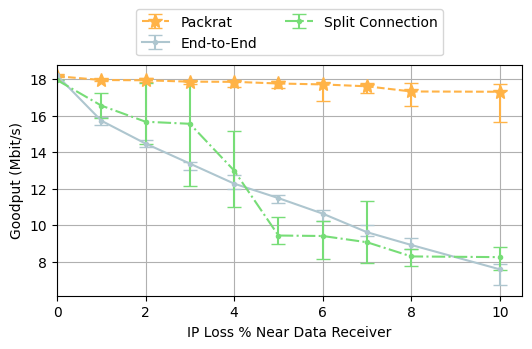

In [8]:
treatments = [treatment_map(label) for label in [f'picoquic_iblt_{ACK_DELAY_WIFI}ms_hint_bbr', 'picoquic_bbr', 'picoquic_split_bbr']]
exec_single(treatments=treatments, network_settings=networks['wifi'], label="http_benchmark_wifi_bbr_solo", execute=True)

Packrat [(0.0, 17.90135330674287), (1.0, 17.32218903665143), (2.0, 17.06372797530558), (3.0, 16.76419232449024), (4.0, 16.63339287274062), (5.0, 15.860852340543008), (6.0, 14.525161819286167), (7.0, 15.227265553572558), (8.0, 12.823703503093657), (10.0, 10.887202190136033)]
End-to-End [(0.0, 18.010280094585404), (1.0, 14.977364341986265), (2.0, 14.219798784419176), (3.0, 13.328109824510182), (4.0, 12.439096261162678), (5.0, 11.878353780975615), (6.0, 11.190586344552518), (7.0, 10.319595553402564), (8.0, 9.875644115204153), (10.0, 8.355866512635934)]
Split Connection [(0.0, 18.15566906761316), (1.0, 18.15143581359439), (2.0, 18.161070000390247), (3.0, 18.156257508360905), (4.0, 18.140039660747554), (5.0, 18.13968379743161), (6.0, 18.110827093367167), (7.0, 18.04992096597257), (8.0, 18.064793038244325), (10.0, 17.750606106558337)]
../figures/http_benchmark_cell_bbr_solo.pdf


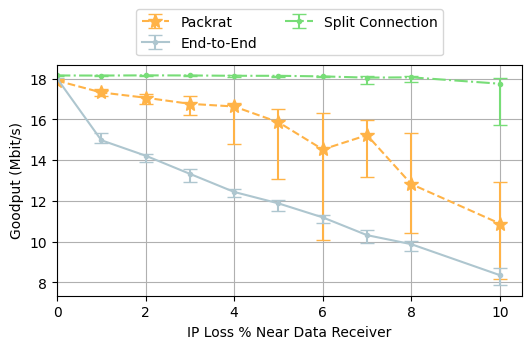

In [9]:
treatments = [treatment_map(label) for label in [f'picoquic_iblt_{ACK_DELAY_CELL}ms_hint_bbr', 'picoquic_bbr', 'picoquic_split_bbr']]
exec_single(treatments=treatments, network_settings=networks['cellular'], label="http_benchmark_cell_bbr_solo", execute=True)

Packrat [(0.0, 16.610687497288687), (1.0, 15.89749804102502), (2.0, 15.669051638999267), (3.0, 15.146056770204003), (4.0, 14.974433478355515), (5.0, 14.588957434054272), (6.0, 13.955618043936923), (7.0, 5.0056255937799925), (8.0, 4.962182537601922), (10.0, 3.560326396285513)]
End-to-End [(0.0, 16.952247586467493), (1.0, 16.851009700433856), (2.0, 16.374783755002124), (3.0, 15.563220089766418), (4.0, 14.838119448818937), (5.0, 14.043789842002738), (6.0, 13.43075014147582), (7.0, 12.921660822873065), (8.0, 12.118116755538026), (10.0, 11.189579927341745)]
Split Connection [(0.0, 17.520853116864853), (1.0, 17.496835989773757), (2.0, 17.44736333972518), (3.0, 17.423091800201995), (4.0, 17.402083114095603), (5.0, 17.42082575583408), (6.0, 17.287185821244744), (7.0, 17.21648979983508), (8.0, 17.004883121266126), (10.0, 16.51287920531516)]
../figures/http_benchmark_sat_bbr_solo.pdf


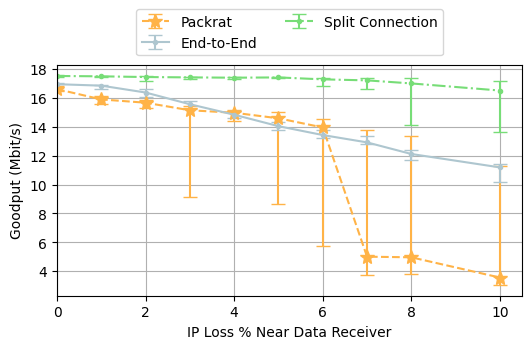

In [10]:
treatments = [treatment_map(label) for label in [f'picoquic_iblt_{ACK_DELAY_SAT}ms_hint_bbr', 'picoquic_bbr', 'picoquic_split_bbr']]
LOSS1_VALUES_ = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10]
max_networks_sat = {'picoquic' : 8}
networks_ = network_settings(LOSS1_VALUES_)
exec_single(treatments=treatments, network_settings=networks_['sat'], max_networks_=max_networks_sat, label="http_benchmark_sat_bbr_solo", execute=True)

## Packrat vs. Other Mechanisms

### CUBIC Results

Packrat [(0.0, 18.434897924738436), (1.0, 18.4585090681001), (2.0, 18.45573685487682), (3.0, 18.425955226399516), (4.0, 18.410458126129413), (5.0, 18.395038561623675), (6.0, 18.386890689084467), (7.0, 18.119640810182283), (8.0, 18.08607114232921), (10.0, 17.17427176177812), (12.0, 14.234962109526087), (14.0, 11.107679186417151), (16.0, 8.816008619607498), (18.0, 7.072632351215758), (20.0, 5.925775901841897), (22.0, 4.3759382814102885), (24.0, 4.1208866137679525)]
End-to-End [(0.0, 18.505101489160992), (1.0, 18.311678789097655), (2.0, 16.520795802989376), (3.0, 10.892711264504715), (4.0, 6.788554765533933), (5.0, 4.634019917365077), (6.0, 3.504319975500283), (7.0, 2.872453767641124), (8.0, 2.305887972775987), (10.0, 1.720879339544157)]
Split Connection [(0.0, 18.578001669913494), (1.0, 18.580464637749216), (2.0, 18.576639320234495), (3.0, 18.57749360913504), (4.0, 18.57088979595244), (5.0, 18.56707864188523), (6.0, 18.54764996115295), (7.0, 18.566643999818446), (8.0, 18.530941063201798)

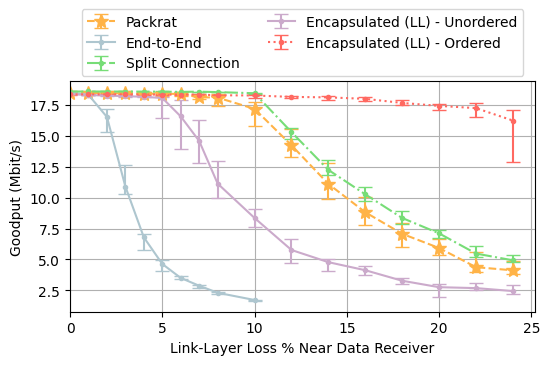

In [48]:
# CUBIC, WIFI network
treatments = [t for t in treatments_cubic if ('iblt' not in t.label() or f'{ACK_DELAY_WIFI}ms' in t.label())]
exec_single(treatments=treatments, network_settings=networks['wifi'], label="http_benchmark_wifi_cubic", execute=True)

Packrat [(0.0, 18.27023859747943), (1.0, 18.041593436041616), (2.0, 17.212388547474916), (3.0, 15.270116089902237), (4.0, 13.127111306475735), (5.0, 12.049338179450551), (6.0, 10.868595133789377), (7.0, 10.03824395351111), (8.0, 9.373003123859517), (10.0, 8.296493189067943), (12.0, 7.445961051305851), (14.0, 6.260498048211035), (16.0, 5.4154386984711405), (18.0, 4.330979428533034), (20.0, 3.293738323428789), (22.0, 2.950924722412789), (24.0, 2.396548518496969)]
End-to-End [(0.0, 18.389689539629998), (1.0, 18.192939132732185), (2.0, 17.620313397313943), (3.0, 9.885183354409513), (4.0, 6.141921432395983), (5.0, 3.8400044173993564), (6.0, 3.108254147005836), (7.0, 2.3912798291335493), (8.0, 1.9591687189824827), (10.0, 1.4316883019805287)]
Split Connection [(0.0, 18.52074874135463), (1.0, 18.5128266922361), (2.0, 18.508556535284683), (3.0, 18.47709267955767), (4.0, 16.429868509988363), (5.0, 12.208018150192363), (6.0, 9.620861268568646), (7.0, 7.568711875152319), (8.0, 6.290340552475358), 

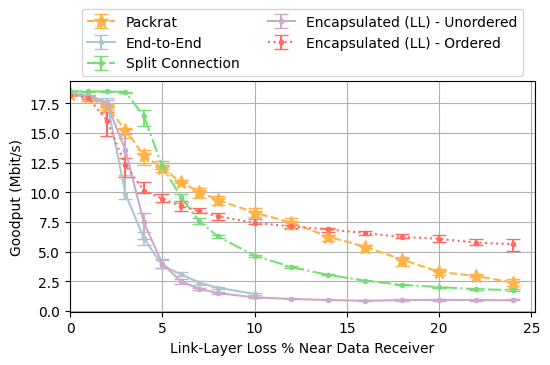

In [49]:
# CUBIC, cellular network
treatments = [t for t in treatments_cubic if ('iblt' not in t.label() or f'{ACK_DELAY_CELL}ms' in t.label())]
exec_single(treatments=treatments, network_settings=networks['cellular'], label="http_benchmark_cell_cubic", execute=True)

Packrat [(0.0, 17.60600923090399), (1.0, 17.292438107289886), (2.0, 14.564253298353385), (3.0, 8.660501895047602), (4.0, 5.20715592632374), (5.0, 4.679049587541741), (6.0, 4.279700128465651), (7.0, 4.132188352612302), (8.0, 3.9436227498242955), (10.0, 3.8665974324073886)]
End-to-End [(0.0, 17.82487994087898), (1.0, 17.647023529498977), (2.0, 15.759349784481987), (3.0, 7.721788039672871), (4.0, 3.993019652803338), (5.0, 2.459938211832621), (6.0, 1.7139903859428354), (7.0, 1.3446420905169485)]
Split Connection [(0.0, 18.13297257671058), (1.0, 18.10080229441462), (2.0, 18.071492624168094), (3.0, 14.990114285076551), (4.0, 8.44287683082716), (5.0, 4.812949636246684), (6.0, 3.6654715901575137), (7.0, 2.9020290470226255), (8.0, 2.3601066899725422), (10.0, 1.6577325209934297)]
Encapsulated (LL) - Unordered [(0.0, 17.711974656759047), (1.0, 17.519764029307332), (2.0, 15.634389289317369), (3.0, 9.790006311250746), (4.0, 5.3295218951548335), (5.0, 3.121054540296477), (6.0, 1.9871784492622504), (

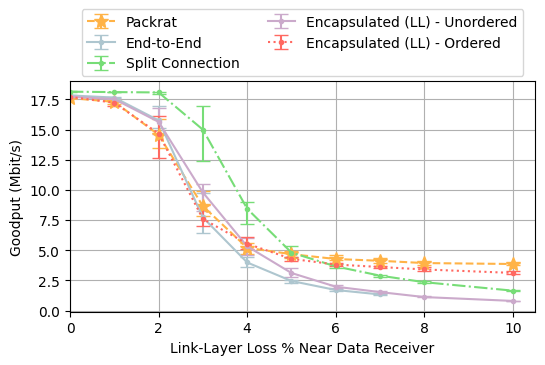

In [50]:
# CUBIC, satellite network:
# - NETWORK_SETTING_SAT = 30ms delay on near path;  NetworkSetting(bw1=50, bw2=20, delay1=30, delay2=50); ACK delay=60ms
LOSS1_VALUES_ = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10]
max_networks_sat = {'picoquic' : 8}
networks_ = network_settings(LOSS1_VALUES_)
treatments = [t for t in treatments_cubic if ('iblt' not in t.label() or f'{ACK_DELAY_SAT}ms' in t.label())]
exec_single(treatments=treatments, network_settings=networks_['sat'], max_networks_=max_networks_sat, label="http_benchmark_sat_cubic", execute=True)

### Impacts of Bursty Loss

17
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 2 --delay2 30 --ge 3.32,29.02,80,2 -t 1 --label picoquic --network-statistics picoquic --client-quacker -n 25000000 111.29593873023987
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 2 --delay2 30 --ge 2.25,19.64,80,2 -t 1 --label picoquic --network-statistics picoquic --client-quacker -n 25000000 88.91425895690918
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 2 --delay2 30 --ge 1.17,10.27,80,2 -t 1 --label picoquic --network-statistics picoquic --client-quacker -n 25000000 85.80469560623169
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 2 --delay2 30 --ge 0.51,4.49,80,2 -t 1 --label picoquic --network-statistics picoquic --client-quacker -n 25000000 54.2222900390625
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 2 --delay2 30 --ge 0.21,1.79,80,2 -t 1 --label picoquic --network-statistics picoquic --client-quacker -n 25000000 74.38036751747131
sudo -E python3 emulatio

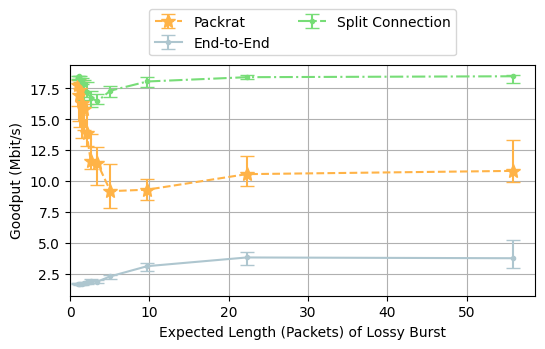

In [27]:
N_TRIALS=20
exec_single_ge(10, 'wifi', ACK_DELAY_WIFI)

36
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 10 --delay2 30 --ge 1,0,10,10 -t 1 --label picoquic_iblt_40ms_hint --proxy sidekick --freq-pkts 16 --freq-ms 2 --threshold 160 --riblt --quack-hint --network-statistics picoquic --client-quacker --ack-delay 40 -n 25000000 17.835545301437378
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 10 --delay2 30 --ge 9.74,85.26,80,2 -t 1 --label picoquic_iblt_40ms_hint --proxy sidekick --freq-pkts 16 --freq-ms 2 --threshold 160 --riblt --quack-hint --network-statistics picoquic --client-quacker --ack-delay 40 -n 25000000 18.359779596328735
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 10 --delay2 30 --ge 8.67,75.88,80,2 -t 1 --label picoquic_iblt_40ms_hint --proxy sidekick --freq-pkts 16 --freq-ms 2 --threshold 160 --riblt --quack-hint --network-statistics picoquic --client-quacker --ack-delay 40 -n 25000000 18.746179580688477
sudo -E python3 emulation/main.py --bw1 50 --bw2 20 --delay1 10 --delay2 30 --g

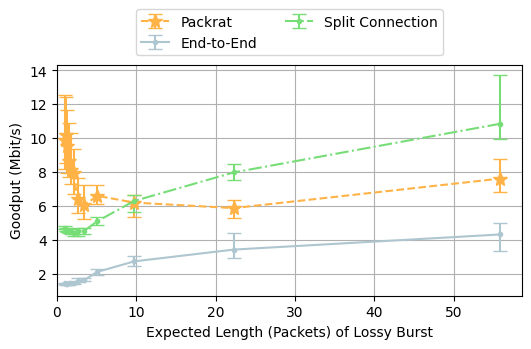

In [28]:
exec_single_ge(10, 'cellular', ACK_DELAY_CELL)

### BBRv3 Results

Packrat [(0.0, 18.155066691596495), (1.0, 17.94783127042991), (2.0, 17.932994632212136), (3.0, 17.85717637160314), (4.0, 17.848312445462398), (5.0, 17.757091277091668), (6.0, 17.70624474303054), (7.0, 17.602748633702397), (8.0, 17.319981142644508), (10.0, 17.304759811820162), (12.0, 14.565748416349741), (14.0, 12.944811636127543), (16.0, 7.709427243135049), (18.0, 7.634463177523138), (20.0, 7.027992517902867), (22.0, 5.027823082494242), (24.0, 4.651522290926089)]
End-to-End [(0.0, 18.197131895940004), (1.0, 15.720818146414306), (2.0, 14.465937187811878), (3.0, 13.372114331683216), (4.0, 12.273628524847371), (5.0, 11.48201766902903), (6.0, 10.631381910440044), (7.0, 9.614770335565032), (8.0, 8.915808972707811), (10.0, 7.581583503455343), (12.0, 6.30935139869337), (14.0, 4.493057274453067), (16.0, 3.224020543813336), (18.0, 1.8447954914689606), (20.0, 1.4196064311945882), (22.0, 1.1520480452903339), (24.0, 1.0211319625753261)]
Split Connection [(0.0, 17.945960215968995), (1.0, 16.5472850

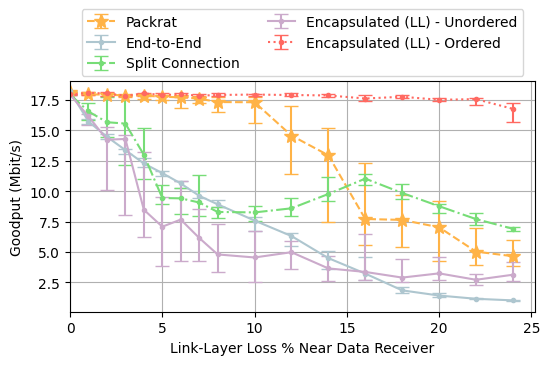

In [57]:
# Wifi
N_TRIALS=20
treatments = [t for t in treatments_bbr if ('iblt' not in t.label() or f'{ACK_DELAY_WIFI}ms' in t.label())]
exec_single(treatments=treatments, network_settings=networks['wifi'], label="http_benchmark_wifi_bbr3", execute=True)

Packrat [(0.0, 17.90135330674287), (1.0, 17.32218903665143), (2.0, 17.06372797530558), (3.0, 16.76419232449024), (4.0, 16.63339287274062), (5.0, 15.860852340543008), (6.0, 14.525161819286167), (7.0, 15.227265553572558), (8.0, 12.823703503093657), (10.0, 10.887202190136033), (12.0, 6.712868801523788), (14.0, 4.302711970283154), (16.0, 4.232544279270677), (18.0, 3.8253226930072906), (20.0, 3.069273589564883), (22.0, 2.8091643523106793), (24.0, 2.1226880261883236)]
End-to-End [(0.0, 18.010280094585404), (1.0, 14.977364341986265), (2.0, 14.219798784419176), (3.0, 13.328109824510182), (4.0, 12.439096261162678), (5.0, 11.878353780975615), (6.0, 11.190586344552518), (7.0, 10.319595553402564), (8.0, 9.875644115204153), (10.0, 8.355866512635934), (12.0, 4.488501737579934), (14.0, 3.273881215326411), (16.0, 2.3774251758446456), (18.0, 1.5268371704594634), (20.0, 1.2105292135809895), (22.0, 0.9198844511795368), (24.0, 0.8269067277692019)]
Split Connection [(0.0, 18.15566906761316), (1.0, 18.15143

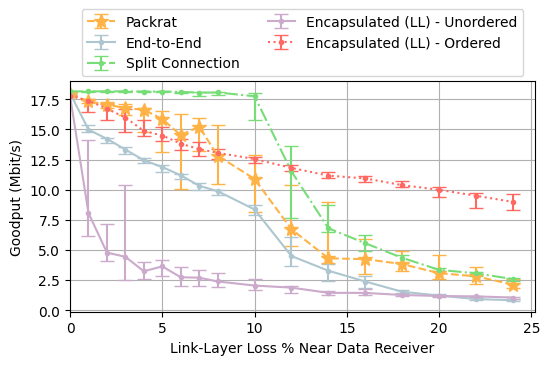

In [58]:
# Cellular
treatments = [t for t in treatments_bbr if ('iblt' not in t.label() or f'{ACK_DELAY_CELL}ms' in t.label())]
exec_single(treatments=treatments, network_settings=networks['cellular'], label="http_benchmark_cell_bbr3", execute=True)

Packrat [(0.0, 16.610687497288687), (1.0, 15.89749804102502), (2.0, 15.669051638999267), (3.0, 15.146056770204003), (4.0, 14.974433478355515), (5.0, 14.588957434054272), (6.0, 13.955618043936923), (7.0, 5.0056255937799925), (8.0, 4.962182537601922), (10.0, 3.560326396285513)]
End-to-End [(0.0, 16.952247586467493), (1.0, 16.851009700433856), (2.0, 16.374783755002124), (3.0, 15.563220089766418), (4.0, 14.838119448818937), (5.0, 14.043789842002738), (6.0, 13.43075014147582), (7.0, 12.921660822873065), (8.0, 12.118116755538026), (10.0, 11.189579927341745)]
Split Connection [(0.0, 17.520853116864853), (1.0, 17.496835989773757), (2.0, 17.44736333972518), (3.0, 17.423091800201995), (4.0, 17.402083114095603), (5.0, 17.42082575583408), (6.0, 17.287185821244744), (7.0, 17.21648979983508), (8.0, 17.004883121266126), (10.0, 16.51287920531516)]
Encapsulated (LL) - Unordered [(0.0, 16.867046095879097), (1.0, 8.902962589050318), (2.0, 3.131418339951524), (3.0, 2.621099201613436), (4.0, 3.356469842657

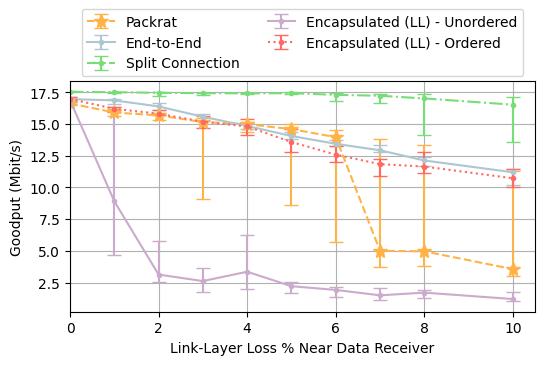

In [59]:
# Satellite
LOSS1_VALUES_ = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10]
max_networks_sat = {'picoquic' : 8}
networks_ = network_settings(LOSS1_VALUES_)
treatments = [t for t in treatments_bbr if ('iblt' not in t.label() or f'{ACK_DELAY_SAT}' in t.label())]
exec_single(treatments=treatments, network_settings=networks_['sat'], label="http_benchmark_sat_bbr", max_networks_=max_networks_sat, execute=True)

Packrat [(0.0, 16.4935478371902), (1.0, 15.169080807258732), (2.0, 14.670875353978051), (3.0, 14.494422095793439), (4.0, 14.133334049402073), (5.0, 13.974667338626913), (6.0, 13.375378060989949), (7.0, 13.490651083760845), (8.0, 12.331348658317598), (10.0, 11.985219620286438)]
End-to-End [(0.0, 17.093714932490272), (1.0, 16.49344910993045), (2.0, 16.010542227842933), (3.0, 15.63334068195942), (4.0, 15.032410543274537), (5.0, 14.55487102483838), (6.0, 14.254018257104754), (7.0, 13.67621634077539), (8.0, 13.099625772502728), (10.0, 12.202719429947212)]
Split Connection [(0.0, 15.897090439638365), (1.0, 15.876786787658837), (2.0, 15.904903361489307), (3.0, 15.834503016071533), (4.0, 15.833605022340077), (5.0, 15.788067167176902), (6.0, 15.772957526051464), (7.0, 15.650426072291342), (8.0, 15.489217059598595), (10.0, 13.966813562974071)]
Encapsulated (LL) - Unordered [(0.0, 16.63173804397293), (1.0, 16.00380302257181), (2.0, 15.679697041927188), (3.0, 15.260198476609627), (4.0, 14.82753900

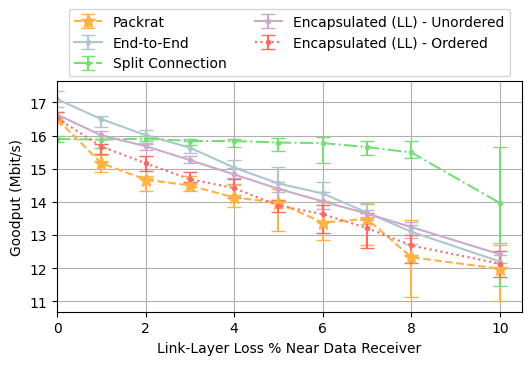

In [5]:
# Sat - long
LOSS1_VALUES_ = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10]
max_networks_sat = {'picoquic' : 8}
networks_ = network_settings(LOSS1_VALUES_)
treatments = [t for t in treatments_bbr if ('iblt' not in t.label() or f'{ACK_DELAY_SAT}' in t.label())]
exec_single(treatments=treatments, network_settings=networks_['sat_long'], label="http_benchmark_sat_long_bbr", max_networks_=max_networks_sat, execute=True)